In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/content/house_price.csv')
df.head()

,area,rooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


#1. EDA / Exploratory Data Analysis

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    47 non-null     int64
 1   rooms   47 non-null     int64
 2   price   47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [10]:
df.describe()

,area,rooms,price
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


In [11]:
df.isnull().sum()

,0
area,0
rooms,0
price,0


In [12]:
df.duplicated().sum()

np.int64(0)

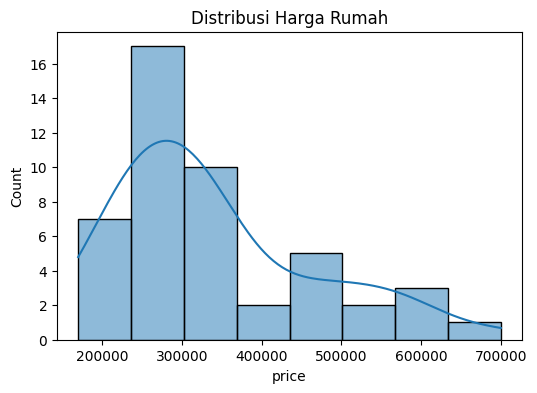

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title('Distribusi Harga Rumah')
plt.show()

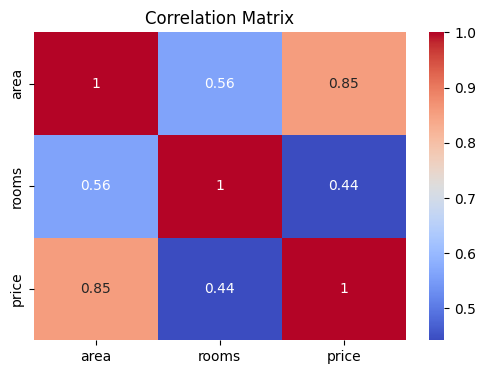

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

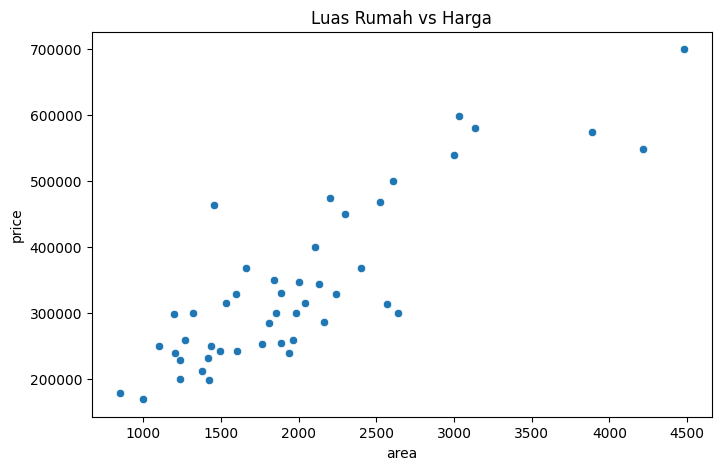

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['area'], y=df['price'])
plt.title('Luas Rumah vs Harga')
plt.show()

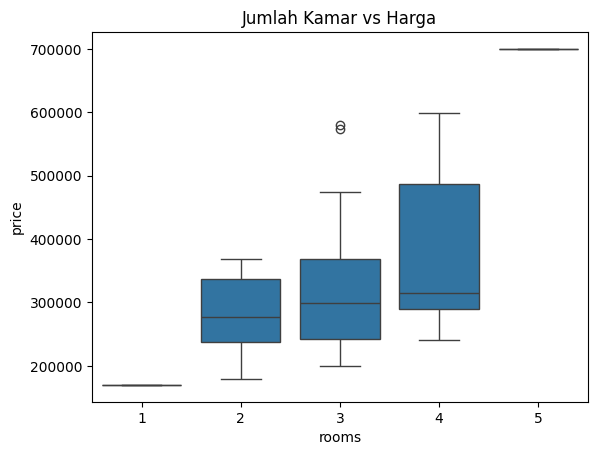

In [16]:
sns.boxplot(x=df['rooms'], y=df['price'])
plt.title('Jumlah Kamar vs Harga')
plt.show()

#Kesimpulan 1 :
1. Dataset memiliki sekian baris dan kolom.
2. Tidak terdapat missing value yang signifikan.
3. Area rumah memiliki korelasi tinggi terhadap harga rumah.
4. Semakin besar luas rumah maka harga cenderung meningkat.
5. Terdapat beberapa outlier pada harga rumah.

#2. Data Preprocessing

In [17]:
#menangani missing value
df['area'].fillna(df['area'].mean(), inplace=True)

/tmp/ipykernel_3150/1920383022.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['area'].fillna(df['area'].mean(), inplace=True)


In [18]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [19]:
#encoding data kategori
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [20]:
df.head()

,area,rooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [21]:
#pisahkan feature dan target
X = df.drop('price', axis=1)
y = df['price']

In [22]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
#feature scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
#cek shape data
print(X_train.shape)
print(X_test.shape)

(37, 2)
(10, 2)


#Kesimpulan 2 :
1. Missing value berhasil ditangani.
2. Duplicate data berhasil dicek dan dibersihkan.
3. Data kategorikal berhasil diencoding.
4. Dataset berhasil dibagi menjadi data training dan testing.
5. Feature scaling berhasil dilakukan sehingga data siap digunakan untuk machine learning.

# 3. Machine Learning Modeling

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [31]:
# Training Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluasi Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Training Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluasi Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

Random Forest
MAE : 72252.42199999999
RMSE : 92115.80650926908
R2 Score : 0.5219332246253191


In [32]:
# Membandingkan Model
import pandas as pd

hasil = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

hasil

,Model,MAE,RMSE,R2 Score
0,Linear Regression,72334.753604,92792.373311,0.514885
1,Random Forest,72252.422000,92115.806509,0.521933


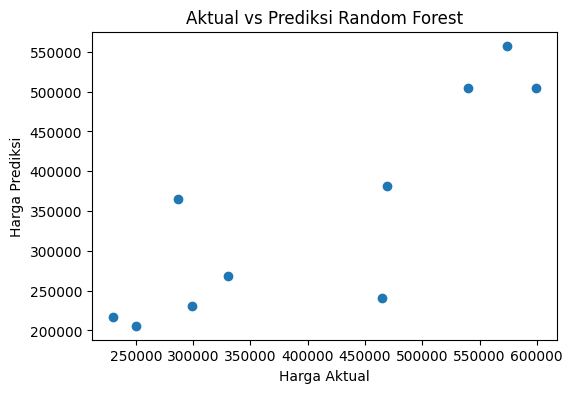

In [35]:
# Visualisasi Prediksi vs Aktual untuk Random Forest karena lebih baik
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")

plt.title(
    "Aktual vs Prediksi Random Forest"
)

plt.show()

In [36]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,area,0.94199
1,rooms,0.05801


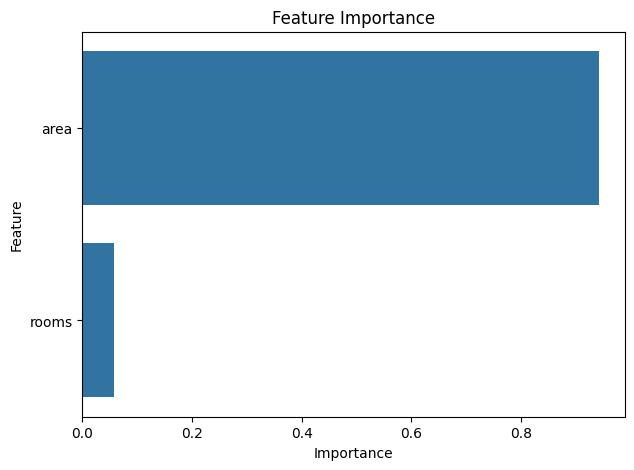

In [38]:
# Visualisasi Feature Importance
plt.figure(figsize=(7,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance'
)

plt.show()

In [42]:
import os

os.makedirs('model', exist_ok=True)

In [43]:
import pickle

pickle.dump(
    rf,
    open('model/model.pkl', 'wb')
)

In [46]:
import pickle

model = pickle.load(open('model/model.pkl', 'rb'))

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [47]:
model.predict(X_test[:5])

array([380856.52, 364677.  , 240914.85, 230728.  , 557650.98])

#Kesimpulan 3 :

1. Dua model machine learning berhasil dilatih, yaitu Linear Regression dan Random Forest Regressor.

2. Evaluasi model dilakukan menggunakan MAE, RMSE, dan R² Score.

3. Random Forest Regressor menghasilkan performa terbaik dengan nilai MAE dan RMSE yang lebih rendah serta R² Score yang lebih tinggi dibandingkan Linear Regression.

4. Feature importance menunjukkan bahwa luas rumah (area) merupakan faktor yang paling berpengaruh terhadap harga rumah.

5. Model terbaik berhasil disimpan dalam format .pkl dan siap digunakan pada aplikasi Streamlit pada tahap berikutnya.